# Analyse des facteurs de risque du diabète
**Dataset :** Diabetes Health Indicators — 253 680 patients américains  
**Auteur :** Elodie Ishimwe  
**Date :** Mai 2026  
**Outils :** Python, Pandas, Plotly

## Contexte
Ce projet analyse les facteurs de risque associés au diabète à partir 
d'une enquête de santé publique américaine (BRFSS). L'objectif est 
d'identifier les variables les plus corrélées au diabète de type 2 
(BMI, âge, activité physique, tabagisme...).

## Questions auxquelles on répond
1. Les personnes diabétiques ont-elles un BMI plus élevé ?
2. Le risque augmente-t-il avec l'âge ?
3. Quel est l'impact de l'activité physique et du tabagisme ?
4. Y a-t-il un lien entre maladies cardiaques et diabète ?

## 1. Chargement des données

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_csv("archive/diabetes_012_health_indicators_BRFSS2015.csv")

print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Valeurs manquantes : {df.isnull().sum().sum()}")
df.head()

Dimensions : 253,680 lignes × 22 colonnes
Valeurs manquantes : 0


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 2. Préparation des données
Création de variables lisibles pour l'analyse.

# Labels lisibles
df["Diabete_label"] = df["Diabetes_012"].map({
    0: "Non diabétique",
    1: "Pré-diabétique",
    2: "Diabétique"
})

# Catégories BMI
def categoriser_bmi(bmi):
    if bmi < 18.5: return "Sous-poids"
    elif bmi < 25: return "Normal"
    elif bmi < 30: return "Surpoids"
    else: return "Obésité"

df["BMI_categorie"] = df["BMI"].apply(categoriser_bmi)

# Groupes d'âge
def categoriser_age(age):
    if age <= 3: return "Jeune (18-34 ans)"
    elif age <= 7: return "Adulte (35-54 ans)"
    elif age <= 10: return "Senior (55-69 ans)"
    else: return "Âgé (70+)"

df["Age_groupe"] = df["Age"].apply(categoriser_age)

print("✓ Variables créées avec succès")

## 3. Analyse exploratoire

### Répartition des patients par statut diabète

In [8]:
counts = df["Diabete_label"].value_counts()
print(counts)
print(f"\n→ {counts['Non diabétique']/len(df)*100:.1f}% des patients sont non diabétiques")
print(f"→ {counts['Diabétique']/len(df)*100:.1f}% sont diabétiques")
print(f"→ {counts['Pré-diabétique']/len(df)*100:.1f}% sont pré-diabétiques")

Diabete_label
Non diabétique    213703
Diabétique         35346
Pré-diabétique      4631
Name: count, dtype: int64

→ 84.2% des patients sont non diabétiques
→ 13.9% sont diabétiques
→ 1.8% sont pré-diabétiques


### BMI moyen par statut diabète

In [9]:
bmi_moyen = df.groupby("Diabete_label")["BMI"].mean().round(2)
print(bmi_moyen)
print(f"\n→ Les diabétiques ont un BMI {(bmi_moyen['Diabétique'] - bmi_moyen['Non diabétique']):.1f} points supérieur aux non diabétiques")

Diabete_label
Diabétique        31.94
Non diabétique    27.74
Pré-diabétique    30.72
Name: BMI, dtype: float64

→ Les diabétiques ont un BMI 4.2 points supérieur aux non diabétiques


### Facteurs de risque — vue d'ensemble

In [10]:
facteurs = df.groupby("Diabete_label")[["Smoker", "PhysActivity", "HeartDiseaseorAttack", "HighBP"]].mean().mul(100).round(1)
facteurs.columns = ["% Fumeurs", "% Actifs physiquement", "% Maladies cardiaques", "% Hypertension"]
print(facteurs)

                % Fumeurs  % Actifs physiquement  % Maladies cardiaques  \
Diabete_label                                                             
Diabétique           51.8                   63.1                   22.3   
Non diabétique       43.0                   77.9                    7.2   
Pré-diabétique       49.3                   67.8                   14.3   

                % Hypertension  
Diabete_label                   
Diabétique                75.3  
Non diabétique            37.1  
Pré-diabétique            62.9  


## 4. Visualisations
### Distribution du BMI par statut diabète

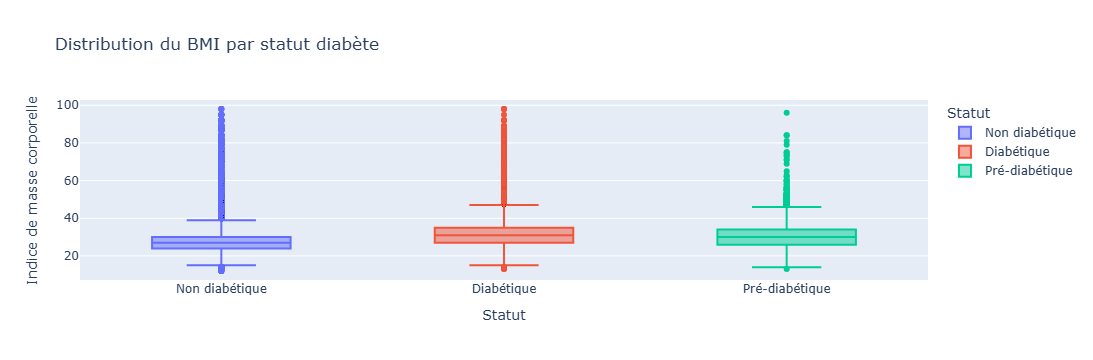

In [11]:
fig = px.box(
    df, x="Diabete_label", y="BMI", color="Diabete_label",
    title="Distribution du BMI par statut diabète",
    labels={"Diabete_label": "Statut", "BMI": "Indice de masse corporelle"}
)
fig.show()

### Répartition des catégories BMI

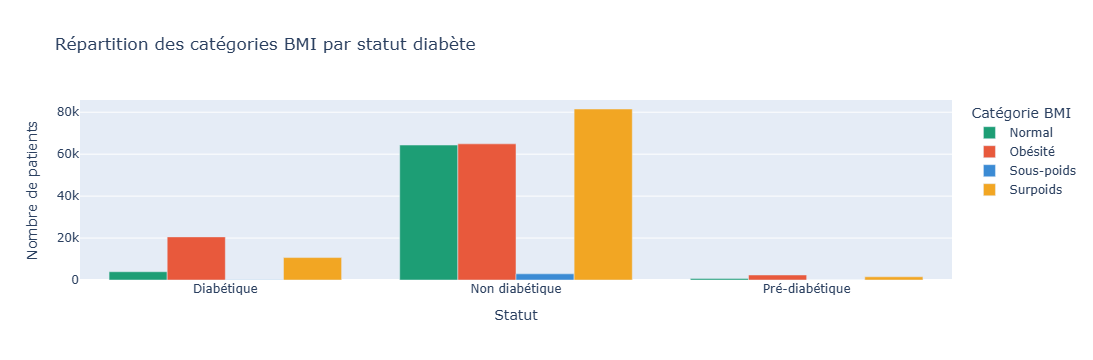

In [12]:
color_map = {
    "Obésité": "#E8593C", "Surpoids": "#F2A623",
    "Normal": "#1D9E75", "Sous-poids": "#3B8BD4"
}
bmi_counts = df.groupby(["Diabete_label", "BMI_categorie"]).size().reset_index(name="count")

fig = px.bar(
    bmi_counts, x="Diabete_label", y="count",
    color="BMI_categorie", barmode="group",
    color_discrete_map=color_map,
    title="Répartition des catégories BMI par statut diabète",
    labels={"Diabete_label": "Statut", "count": "Nombre de patients", "BMI_categorie": "Catégorie BMI"}
)
fig.show()

### Évolution du taux de diabète par âge

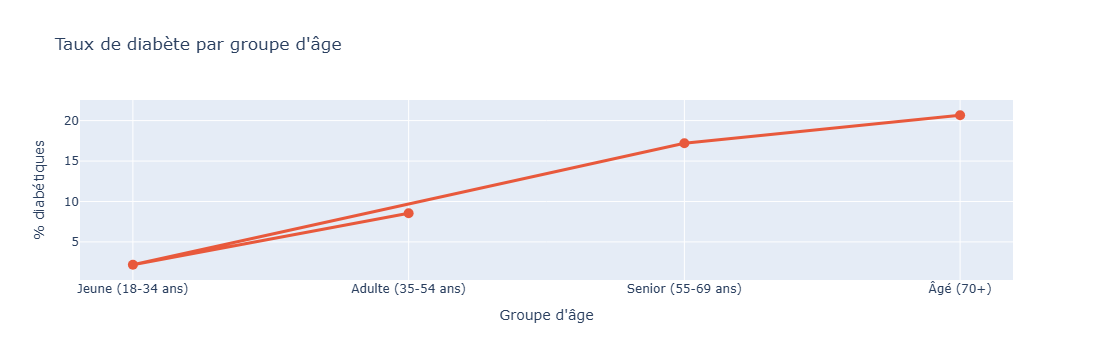

In [13]:
ordre = ["Jeune (18-34 ans)", "Adulte (35-54 ans)", "Senior (55-69 ans)", "Âgé (70+)"]
age_diabetes = df.groupby("Age_groupe")["Diabetes_012"].apply(
    lambda x: (x == 2).sum() / len(x) * 100
).reset_index()
age_diabetes.columns = ["Age_groupe", "taux_diabete"]

fig = px.line(
    age_diabetes, x="Age_groupe", y="taux_diabete",
    markers=True,
    title="Taux de diabète par groupe d'âge",
    labels={"Age_groupe": "Groupe d'âge", "taux_diabete": "% diabétiques"},
    category_orders={"Age_groupe": ordre}
)
fig.update_traces(line_color="#E8593C", line_width=3, marker_size=10)
fig.show()

## 5. Conclusions

- **BMI** : Les diabétiques ont un BMI moyen de 31.9 vs 27.7 chez les non diabétiques
- **Âge** : Le taux de diabète passe de 2% chez les jeunes à 20% chez les 70+
- **Activité physique** : 63% des diabétiques sont actifs vs 78% des non diabétiques
- **Maladies cardiaques** : 3x plus fréquentes chez les diabétiques (22% vs 7%)
- **Tabagisme** : corrélé mais écart modéré (52% vs 43%)

> Le BMI et l'âge sont les deux facteurs les plus fortement associés au diabète dans ce dataset.